# Gantry 2

<html>
<div class="alert alert-info" role="alert" style="margin-top: 10px">
Here the comparisons in between the OPAL map and the particle Tracking were plotted. 
</div>
</html>

In [1]:
from pyH5root import SDDSParser
import numpy as np
import datetime

from matplotlib import rc
import matplotlib.pylab as plt
%matplotlib inline

import sys
from PyQt5.QtGui import *

/opt/anaconda3/lib/python3.6/site-packages/h5py/__init__.py:36: FutureWarning: Conversion of the second argument of issubdtype from `float` to `np.floating` is deprecated. In future, it will be treated as `np.float64 == np.dtype(float).type`.
  from ._conv import register_converters as _register_converters


In [2]:
def plot_quantity(ax, xvar, yvar):
    xdata = s.getDataOfVariable(xvar)
    xunit = s.getUnitOfVariable(xvar)
    
    ydata = s.getDataOfVariable(yvar)
    yunit = s.getUnitOfVariable(yvar)
    
    ax.set_xlabel(xvar + ' [' + xunit + ']')
    ax.set_ylabel(yvar + ' [' + yunit + ']')
    
    ax.plot(xdata, ydata)
    

In [3]:
def opalplot_quantity(s,xvar, yvar,atype):
    plotpath='../pyPlots/'
    
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=150)
    fig.set_size_inches(9,9)
    
    yvarvec=[yvar+"_x", yvar+"_y"]
    
    xdata = s.getDataOfVariable(xvar)
    xunit = s.getUnitOfVariable(xvar)
    
    y1data = s.getDataOfVariable(yvarvec[0])
    y2data = s.getDataOfVariable(yvarvec[1])
    
    yunit = s.getUnitOfVariable(yvar+"_x")
    
    ax1.set_xlabel(xvar + ' [' + xunit + ']')
    ax1.set_ylabel(yvar+"_x" + ' [' + yunit + ']')
    
    ax2.set_xlabel(xvar + ' [' + xunit + ']')
    ax2.set_ylabel(yvar+"_y" + ' [' + yunit + ']')
     
    ax1.plot(xdata, y1data, 'r-')
    ax2 = plt.gca()
    plt.gca().invert_yaxis()
    ax2.plot(xdata, y2data,'b-')
    
    ax1.set_ylim(ymin=0)
    ax2.set_ylim(ymax=0)
    
    ax2.xaxis.set_label_position('top') 
    ax2.xaxis.set_ticks_position('top')
    
    plotpath+=atype+datetime.datetime.now().strftime('%Y-%m-%d_%H:%M:%S')+'.png'  
    fig.subplots_adjust(hspace = .001)
    
    fig.savefig(plotpath)

In [4]:
def opalplot_comp_quantity(fns,xvar, yvar, lattice):
    plotpath='/home/phil/Documents/ETH/MScProj/OPAL/pyPlots/'
    
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, dpi=150)
    fig.set_size_inches(9,4)
    
    yvarvec=[yvar+"_x", yvar+"_y"]
    
    x=[]
    y1=[]
    y2=[]
    xunit=[]
    yunit=[]
    for track in fns:
        x.append(fns[track].getDataOfVariable(xvar))
        y1.append(fns[track].getDataOfVariable(yvarvec[1]))
        y2.append(fns[track].getDataOfVariable(yvarvec[0]))
        
        xunit.append(fns[track].getUnitOfVariable(xvar))
        yunit.append(fns[track].getUnitOfVariable(yvar+"_x"))   
    
    for ax in [ax1,ax2]:
        ax.set_xlabel(xvar + ' [' + xunit[0] + ']')
        
    ax1.set_ylabel(yvar+"_x" + ' [' + yunit[0] + ']')
    ax2.set_ylabel(yvar+"_y" + ' [' + yunit[0] + ']')
   
    ax2 = plt.gca()
    plt.gca().invert_yaxis()
    
    filename=''
    for i, track in enumerate(fns):
        ax1.plot(x[i], y1[i],label=track+ ' [' + yunit[0] + ']')
        ax2.plot(x[i], y2[i])#,label=track+ ' [' + yunit[0] + ']')    
        filename+= track +'_'
        
    ax1.set_ylim(ymin=0,ymax=0.03)
    ax2.set_ylim(ymax=0,ymin=0.03)
    
    ax2.xaxis.set_label_position('top') 
    ax2.xaxis.set_ticks_position('top')
    
    if lattice:
        plotLattice(pathLattice,fig,ax1,ax2)
    
    plotpath+=filename+datetime.datetime.now().strftime('%Y-%m-%d_%H:%M:%S')+'.png'  
    fig.subplots_adjust(hspace = .001)
    fig.suptitle('Comparison OPAL Algorithms')
    fig.legend(loc=4)
    
    fig.savefig(plotpath)

In [45]:
def plotLattice(pathLattice,fig,ax1,ax2):
    import re
    dictPlot={}
  
    pattern_quadrupole=re.compile(r'''QUADRUPOLE \n
                            ''',re.VERBOSE|re.UNICODE)
    pattern_monitor=re.compile(r'''MONITOR \n
                            ''',re.VERBOSE|re.UNICODE)
    pattern_collimator=re.compile(r'''COLLIMATOR \n
                            ''',re.VERBOSE|re.UNICODE)
    pattern_dipole=re.compile(r'''DIPOLE \n
                            ''',re.VERBOSE|re.UNICODE)
    

  
    pattern_corner=re.compile(r'''(?P<name>[A-Z,0-9]*) [\s]+            
            (?P<one>[0-9]+ [.]? [0-9]*) [\s]*
            ((?P<two>[0-9]+ [.]? [0-9]*) [\s]*)?
            ((?P<three>[0-9]+ [.]? [0-9]*) [\s]*)?
            (?P<four>[0-9]+ [.]? [0-9]*)? \s* \n
                            ''',re.VERBOSE|re.UNICODE)
    dictTypes={
        "monitor": [pattern_monitor, 2,'k-'], 
        "collimator":[pattern_collimator,4,'k-'],
        "dipole": [pattern_dipole,5,'b-'],
        "quadrupole":[pattern_quadrupole,5,'r-'],
    }
    
    
    
    with open(pathLattice, 'r') as lattice:
        for p,line in enumerate(lattice):
            
            if p%2==0:
                for eltype in dictTypes:
                    typematch=dictTypes[eltype][0].match(line)
                    if typematch:
                        element=eltype
                        break                    
               
            if p%2==1 and typematch:
                cornermatch= pattern_corner.match(line)
            
                if cornermatch:
                    elem=[]
                    elem.append(element)
                    for i in range(dictTypes[element][1]):
                        elem.append(cornermatch.group(i+1))
                    dictPlot[elem[1]]=elem
                     
            elif(p%2==1 and not typematch):
                print(">[lattice]: not possible to read line:", p)
    
    print(dictPlot)
    for element in dictPlot: 
        
        if dictPlot[element][0]=="monitor":
            x=[float(dictPlot[element][2]),float(dictPlot[element][2])]
            y=[0,0.005]
            ax1.plot(x,y,'k-')
            ax2.plot(x,y,'k-')
            
        elif dictPlot[element][0]=="dipole":            
            x=([float(dictPlot[element][2]),float(dictPlot[element][2]),
               float(dictPlot[element][2])+float(dictPlot[element][3]),
               float(dictPlot[element][2])+float(dictPlot[element][3])])
            
            y=[float(dictPlot[element][5])/2000+.003,float(dictPlot[element][5])/2000,
               float(dictPlot[element][5])/2000,float(dictPlot[element][5])/2000+.003]
            
            ax1.plot(x,y,'r-')
            ax2.plot(x,y,'r-')     
            
        elif dictPlot[element][0]=="quadrupole":
            x=([float(dictPlot[element][2]),float(dictPlot[element][2]),
               float(dictPlot[element][2])+float(dictPlot[element][3]),
               float(dictPlot[element][2])+float(dictPlot[element][3])])
            
            y=[float(dictPlot[element][5])/2000+.003,float(dictPlot[element][5])/2000,
               float(dictPlot[element][5])/2000,float(dictPlot[element][5])/2000+.003]
            
            ax1.plot(x,y,'g-')
            ax2.plot(x,y,'g-')   
            
        
        elif dictPlot[element][0]=="collimator":
            x=[float(dictPlot[element][2]),float(dictPlot[element][2])]
            y=[float(dictPlot[element][3])/2000,float(dictPlot[element][3])/2000+.003]
            y2=[float(dictPlot[element][4])/2000,float(dictPlot[element][4])/2000+.003]
            
            ax1.plot(x,y,'b-')
            ax2.plot(x,y2,'b-')


In [42]:
xvar = 's'
yvar = 'rms'


#opalplot_quantity(mapp,xvar, yvar,'map_')

#plt.show()


In [43]:
xvar = 's'
yvar = 'rms'

#opalplot_quantity(part,xvar, yvar,'parallel-t_')

#plt.show()

>[lattice]: not possible to read line: 51
>[lattice]: not possible to read line: 53
{'QMB3': ['quadrupole', 'QMB3', '32.632', '0.368 ', '0.368', '46.5 '], 'QMB4': ['quadrupole', 'QMB4', '33.202', '0.368 ', '0.368', '46.5 '], 'QMB5': ['quadrupole', 'QMB5', '33.772', '0.368 ', '0.368', '46.5 '], 'MMBP7X': ['monitor', 'MMBP7X', '34.4575'], 'MMBP8Y': ['monitor', 'MMBP8Y', '34.4575'], 'KMB1': ['collimator', 'KMB1', '36.058', '15 ', '15'], 'MMBP9X': ['monitor', 'MMBP9X', '36.1971'], 'MMBP10Y': ['monitor', 'MMBP10Y', '36.1971'], 'MMFP1X': ['monitor', 'MMFP1X', '37.3717'], 'MMFP2Y': ['monitor', 'MMFP2Y', '37.3717'], 'QMF1': ['quadrupole', 'QMF1', '37.6502', '0.32 ', '0.32', '38 '], 'QMF2': ['quadrupole', 'QMF2', '38.2802', '0.32 ', '0.32', '38 '], 'AMF1': ['dipole', 'AMF1', '39.0362', '1.5586 ', '1.5586', '46.5 '], 'MMFP3X': ['monitor', 'MMFP3X', '40.9898'], 'MMFP4Y': ['monitor', 'MMFP4Y', '40.9898'], 'QMF3': ['quadrupole', 'QMF3', '41.2565', '0.32 ', '0.32', '38 '], 'QMF4': ['quadrupole', 'QM

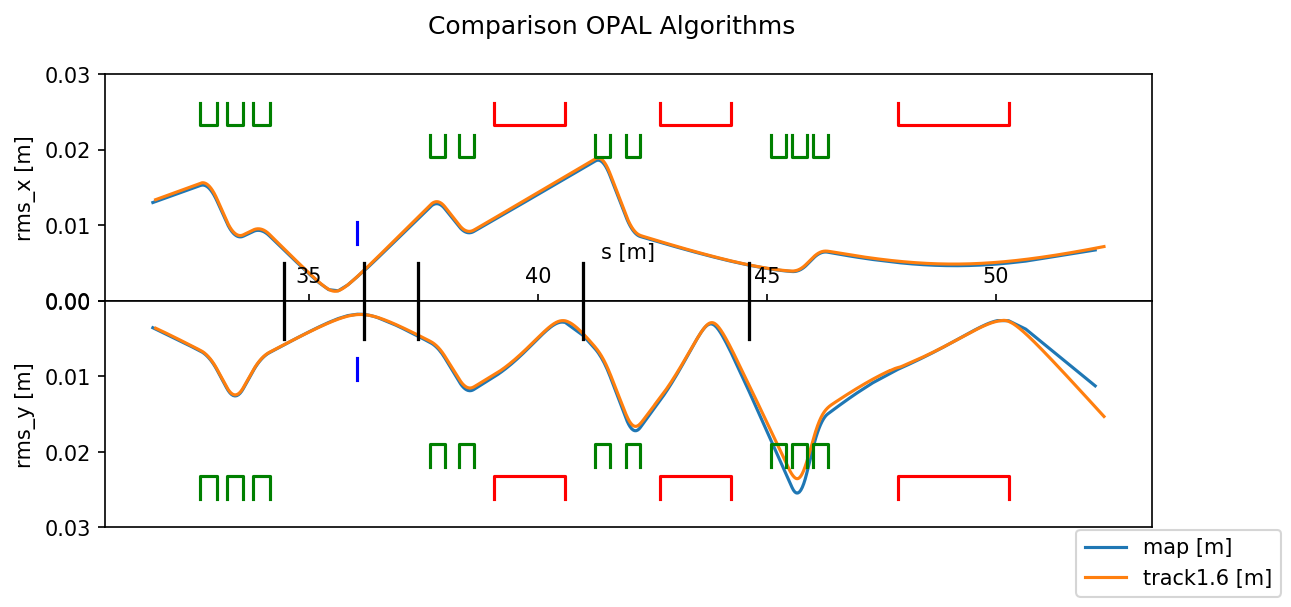

In [44]:
fns = {}
fns['map']='/home/phil/Documents/ETH/MScProj/OPAL/src/tests/Maps/Gantry2/map/70MeV_Gantry2.stat'
#fns['map angles']='/home/phil/Documents/ETH/MScProj/OPAL/src/tests/Maps/Gantry2/map_angles/70MeV_Gantry2.stat'

fns['track1.6'] ='/home/phil/Documents/ETH/MScProj/OPAL16/src/tests/MyData/normAMF2/70MeV_Gantry2.stat'
#fns['track1.6 angles'] ='/home/phil/Documents/ETH/MScProj/OPAL16/src/tests/MyData/angles/70MeV_Gantry2.stat'

#fns['track1.9'] = '/home/phil/Documents/ETH/MScProj/OPAL/src/tests/Maps/Gantry2/track/70MeV_Gantry2.stat'
#fns['negative K0 opal-1.9'] = '/home/phil/Documents/ETH/MScProj/OPAL/src/tests/Maps/Gantry2/track/70MeV_Gantry2.stat'
#fns['rotate AMF2 opal-1.9'] = '/home/phil/Documents/ETH/MScProj/OPAL/src/tests/Maps/Gantry2/rotateAMF2/70MeV_Gantry2.stat'
#fns['negative K0 opal-1.6'] ='/home/phil/Documents/ETH/MScProj/OPAL16/src/tests/MyData/normAMF2/70MeV_Gantry2.stat'

pathLattice=r'/home/phil/Documents/ETH/MScProj/OPAL/src/tests/Maps/Gantry2/map/70MeV_G2.lattice'
# fns.append('/Users/adelmann/Desktop/v1.6/RFphotoinjector-1.6.stat')


SDDSdict={}
for statfile in fns:
    filepath= fns[statfile]
    SDDSdict[statfile]=SDDSParser()
    SDDSdict[statfile].parse(filepath)
    
xvar = 's'
yvar = 'rms'

opalplot_comp_quantity(SDDSdict,xvar, yvar,True)

plt.show()